**HOUSING PRICE PREDICTION**

In [1]:
import pandas as pd
import numpy as np
import sklearn
from sklearn.datasets import fetch_california_housing

In [3]:
sklearn.datasets.fetch_california_housing( data_home=None, download_if_missing=True, return_X_y=False, as_frame=False, n_retries=3, delay=1.0)


{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [4]:
hs = fetch_california_housing()
hs

{'data': array([[   8.3252    ,   41.        ,    6.98412698, ...,    2.55555556,
           37.88      , -122.23      ],
        [   8.3014    ,   21.        ,    6.23813708, ...,    2.10984183,
           37.86      , -122.22      ],
        [   7.2574    ,   52.        ,    8.28813559, ...,    2.80225989,
           37.85      , -122.24      ],
        ...,
        [   1.7       ,   17.        ,    5.20554273, ...,    2.3256351 ,
           39.43      , -121.22      ],
        [   1.8672    ,   18.        ,    5.32951289, ...,    2.12320917,
           39.43      , -121.32      ],
        [   2.3886    ,   16.        ,    5.25471698, ...,    2.61698113,
           39.37      , -121.24      ]]),
 'target': array([4.526, 3.585, 3.521, ..., 0.923, 0.847, 0.894]),
 'frame': None,
 'target_names': ['MedHouseVal'],
 'feature_names': ['MedInc',
  'HouseAge',
  'AveRooms',
  'AveBedrms',
  'Population',
  'AveOccup',
  'Latitude',
  'Longitude'],
 'DESCR': '.. _california_housing_dataset:\n

In [9]:
# Convert to pandas DataFrame for easier handling
hs_df = pd.DataFrame(hs.data, columns=hs.feature_names)

# Check for missing values
print("Missing values per column:")
print(hs_df.isnull().sum())


Missing values per column:
MedInc        0
HouseAge      0
AveRooms      0
AveBedrms     0
Population    0
AveOccup      0
Latitude      0
Longitude     0
dtype: int64


In [10]:
hs_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
dtypes: float64(8)
memory usage: 1.3 MB


In [11]:
# Prepare data: Separate features (X) and target (y)
X = hs_df[['Population', 'AveRooms']] # Select the specified features
y = hs.target # The target variable is in hs.target

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)

Features (X) shape: (20640, 2)
Target (y) shape: (20640,)


In [12]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (16512, 2)
X_test shape: (4128, 2)
y_train shape: (16512,)
y_test shape: (4128,)


In [13]:
from sklearn.linear_model import LinearRegression

# Train a Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model training complete.")

Model training complete.


In [14]:
from sklearn.metrics import mean_squared_error, r2_score

# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error (MSE): {mse}")
print(f"R-squared (R2): {r2}")



Mean Squared Error (MSE): 1.2921785224450966
R-squared (R2): 0.013912035172619075


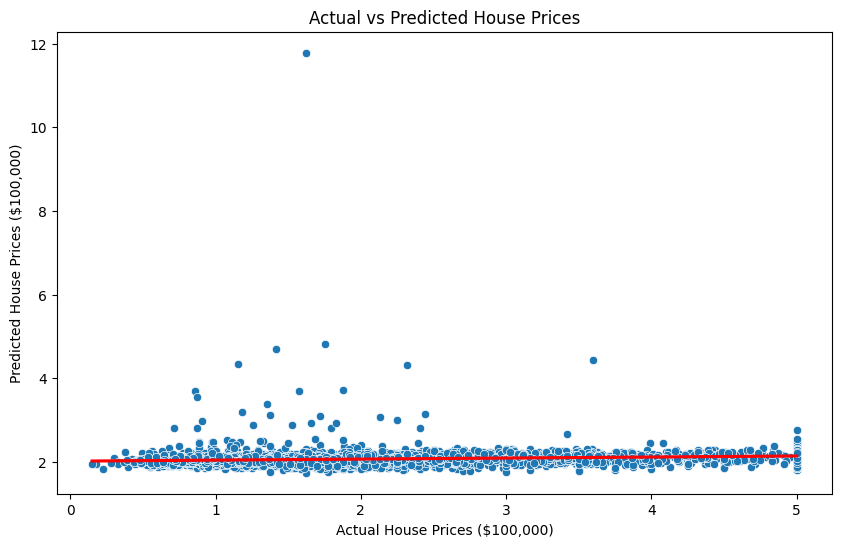

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a scatter plot of actual vs predicted prices
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual House Prices ($100,000)")
plt.ylabel("Predicted House Prices ($100,000)")
plt.title("Actual vs Predicted House Prices")

# Add a regression line
sns.regplot(x=y_test, y=y_pred, scatter=False, color='red')

plt.show()

In [15]:
# Example of predicting house prices for new data
# Let's create a sample new data point with values for 'Population' and 'AveRooms'
new_data = pd.DataFrame({'Population': [1000], 'AveRooms': [5.5]})

# Predict the house price for the new data
predicted_price = model.predict(new_data)

print(f"Predicted house price for the new data: ${predicted_price[0]*100000:.2f}")

Predicted house price for the new data: $208314.01


For this type of problem (predicting a continuous value like house prices), we evaluate the model using metrics like Mean Squared Error (MSE) and R-squared (R2) rather than "accuracy," which is used for classification problems.

- **MSE** measures the average squared difference between actual and predicted values.
- **R-squared** indicates how much of the variance in the target variable is explained by the model.

We have already calculated these metrics, and the R-squared value suggests that the current features don't strongly predict house prices.